In [6]:
# ============================================
# BLOCO 1: IMPORTAÇÕES E CONFIGURAÇÕES INICIAIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')

# Configurações para reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [7]:
# ============================================
# BLOCO 2: CARREGAR E PREPARAR OS DADOS
# ============================================

# Carregar os dados
df = pd.read_csv('../1.Dados/noticias.csv')

print(f"📊 Total de notícias: {len(df)}")
print(f"📋 Colunas: {df.columns.tolist()}")
print("\n🔍 Primeiras linhas:")
display(df.head())

# Verificar valores nulos
print("\n🔍 Valores nulos por coluna:")
print(df.isnull().sum())

# Preencher valores nulos na coluna de texto
df['texto_sem_stopwords'] = df['texto_sem_stopwords'].fillna('')

📊 Total de notícias: 2000
📋 Colunas: ['titulo', 'data', 'visitas', 'texto', 'texto_limpo', 'texto_sem_stopwords']

🔍 Primeiras linhas:


,titulo,data,visitas,texto,texto_limpo,texto_sem_stopwords
0,STJD indefere pedido de suspensão e Abel Ferre...,11/4/2026 16:47,141,O Palmeiras terá uma nova rodada de desafios n...,o palmeiras tera uma nova rodada de desafios n...,palmeiras nova rodada desafios campeonato bras...
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,11/4/2026 16:47,129,O Nubank está explorando a possibilidade de or...,o nubank esta explorando a possibilidade de or...,nubank explorando possibilidade organizar amis...
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,11/4/2026 16:47,105,A Sociedade Esportiva Palmeiras manifestou sua...,a sociedade esportiva palmeiras manifestou sua...,sociedade esportiva palmeiras manifestou insat...
3,Palmeiras encerra treinos para o Dérbi com Vit...,11/4/2026 14:27,276,"Na manhã deste sábado (11), a Academia de Fute...",na manha deste sabado 11 a academia de futebol...,manha deste sabado 11 academia futebol palco u...
4,Messi Pode Anunciar Amistoso Histórico em São ...,11/4/2026 14:07,246,"A co-fundadora do Nubank, Cristina Junqueira, ...",a co fundadora do nubank cristina junqueira re...,co fundadora nubank cristina junqueira revelou...



🔍 Valores nulos por coluna:
titulo                  0
data                    0
visitas                 0
texto                  18
texto_limpo            18
texto_sem_stopwords    18
dtype: int64


In [8]:
# ============================================
# BLOCO 3: CRIAR VARIÁVEL TARGET
# ============================================

# Definir o threshold: 20% das notícias com mais visitas
threshold = np.percentile(df['visitas'], 80)  # 80º percentil = top 20%

# Criar a variável target: 1 = Hot (top 20%), 0 = Not Hot
df['hot'] = (df['visitas'] >= threshold).astype(int)

print(f"\n🎯 Threshold para ser considerado HOT: {threshold:.0f} visitas")
print(f"\n📈 Distribuição da variável target:")
print(df['hot'].value_counts())
print(f"   Hot (1): {df['hot'].sum()} notícias ({df['hot'].mean()*100:.1f}%)")
print(f"   Not Hot (0): {len(df) - df['hot'].sum()} notícias ({(1-df['hot'].mean())*100:.1f}%)")


🎯 Threshold para ser considerado HOT: 1879 visitas

📈 Distribuição da variável target:
hot
0    1600
1     400
Name: count, dtype: int64
   Hot (1): 400 notícias (20.0%)
   Not Hot (0): 1600 notícias (80.0%)


In [9]:
# ============================================
# BLOCO 5: DIVISÃO DOS DADOS
# ============================================

X = df['texto_sem_stopwords']
y = df['hot']

# Primeiro separar treino (60%) e temporário (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Depois dividir o temporário em validação (20%) e teste (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n📊 Divisão dos dados:")
print(f"   Treino: {len(X_train)} notícias ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Validação: {len(X_val)} notícias ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Teste: {len(X_test)} notícias ({len(X_test)/len(df)*100:.1f}%)")

# Verificar a distribuição da target em cada conjunto
print("\n🎯 Distribuição da target em cada conjunto:")
print(f"   Treino - Hot: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Validação - Hot: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"   Teste - Hot: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


📊 Divisão dos dados:
   Treino: 1200 notícias (60.0%)
   Validação: 400 notícias (20.0%)
   Teste: 400 notícias (20.0%)

🎯 Distribuição da target em cada conjunto:
   Treino - Hot: 240 (20.0%)
   Validação - Hot: 80 (20.0%)
   Teste - Hot: 80 (20.0%)



🤖 TREINANDO MODELO EXTRA: TabICL (In-Context Learning)

📝 Vetorizando texto com TF-IDF...

📉 Reduzindo dimensionalidade com SVD (TF-IDF → 200 componentes)...
   Shape treino após SVD: (1200, 200)
   Variância explicada: 48.29%

🔄 Ajustando TabICL (download do checkpoint na 1ª vez)...
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.

🔍 Gerando predições no conjunto de teste...

📊 RESULTADOS - TabICL
   Acurácia:    0.8075
   Precisão:    0.5517
   Recall:      0.2000
   F1-Score:    0.2936
   ROC-AUC:     0.7448

📋 Relatório de Classificação:
              precision    recall  f1-score   support

     Not Hot       0.83      0.96      0.89       320
         Hot       0.55      0.20      0.29        80

    accuracy                           0.81       400
   macro avg       0.69      0.58      0.59       400
weighted avg       0.77      0.81      

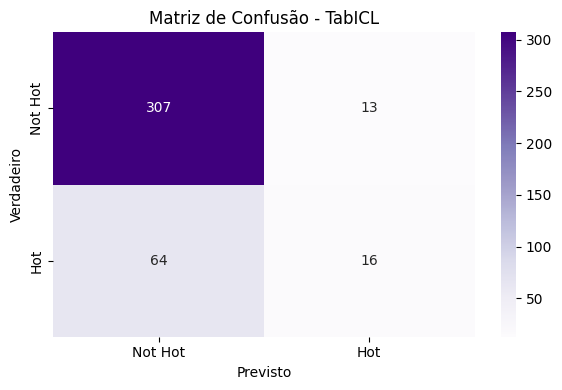

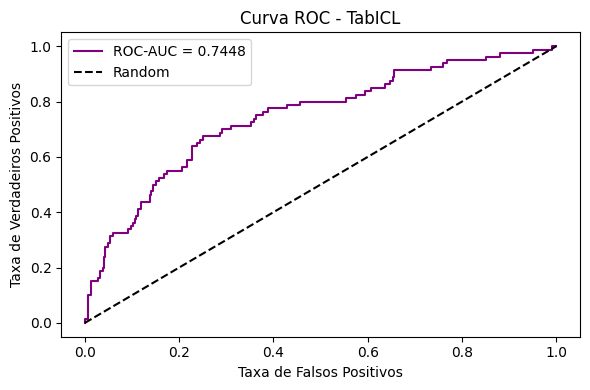


✅ Modelo TabICL finalizado!
📊 Métricas salvas em 'metrics_tabicl'


In [10]:
# ============================================
# BLOCO EXTRA: TabICL para Classificação Binária
# ============================================


from tabicl import TabICLClassifier
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n" + "="*70)
print("🤖 TREINANDO MODELO EXTRA: TabICL (In-Context Learning)")
print("="*70)

# TabICL opera sobre features densas — usar a matriz TF-IDF convertida para array denso
# AVISO: com 5000 features isso pode ser pesado; reduzir dimensionalidade ajuda
from sklearn.decomposition import TruncatedSVD

# Adicionar o passo de vetorização TF-IDF
print("\n📝 Vetorizando texto com TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\n📉 Reduzindo dimensionalidade com SVD (TF-IDF → 200 componentes)...")
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f"   Shape treino após SVD: {X_train_svd.shape}")
print(f"   Variância explicada: {svd.explained_variance_ratio_.sum():.2%}")

# Instanciar e treinar o TabICL
# kv_cache=True acelera muito quando o conjunto de treino é fixo
tabicl = TabICLClassifier(kv_cache=True)

print("\n🔄 Ajustando TabICL (download do checkpoint na 1ª vez)...")
tabicl.fit(X_train_svd, y_train.values)

# Predições no conjunto de teste
print("🔍 Gerando predições no conjunto de teste...")
y_pred_tabicl = tabicl.predict(X_test_svd)
y_prob_tabicl = tabicl.predict_proba(X_test_svd)[:, 1]

# Métricas
acc  = accuracy_score(y_test, y_pred_tabicl)
prec = precision_score(y_test, y_pred_tabicl, zero_division=0)
rec  = recall_score(y_test, y_pred_tabicl, zero_division=0)
f1   = f1_score(y_test, y_pred_tabicl, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_tabicl)

print(f"\n{'='*60}")
print(f"📊 RESULTADOS - TabICL")
print(f"{'='*60}")
print(f"   Acurácia:    {acc:.4f}")
print(f"   Precisão:    {prec:.4f}")
print(f"   Recall:      {rec:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"   ROC-AUC:     {auc:.4f}")
print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_tabicl, target_names=['Not Hot', 'Hot']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_tabicl)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Hot', 'Hot'],
            yticklabels=['Not Hot', 'Hot'])
plt.title('Matriz de Confusão - TabICL')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_tabicl)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='purple', label=f'ROC-AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - TabICL')
plt.legend()
plt.tight_layout()
plt.show()

# Salvar métricas
metrics_tabicl = {
    'model': 'TabICL',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'roc_auc': auc
}

print(f"\n✅ Modelo TabICL finalizado!")
print(f"📊 Métricas salvas em 'metrics_tabicl'")

In [11]:
prob_cal   = tabicl.predict_proba(X_val_svd)
prob_teste = tabicl.predict_proba(X_test_svd)

In [13]:
alpha = 0.10

scores_cal = 1 - prob_cal[np.arange(len(y_val)), y_val]

n_cal = len(scores_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
qhat = np.quantile(scores_cal, nivel_quantil, method="higher")

qhat

np.float32(0.7468418)

In [14]:
conjuntos_pred = prob_teste >= (1 - qhat)

tamanho_medio = conjuntos_pred.sum(axis=1).mean()
cobertura = np.mean([conjuntos_pred[i, y_test.iloc[i]] for i in range(len(y_test))])

pd.Series({
    "qhat": qhat,
    "cobertura": cobertura,
    "tamanho_medio_do_conjunto": tamanho_medio,
})

qhat                         0.746842
cobertura                    0.907500
tamanho_medio_do_conjunto    1.270000
dtype: float64

In [15]:
classes = ["not hot", "hot"]

resumo = pd.DataFrame({
    "y_real": [classes[c] for c in y_test],
    "prob_not_hot": prob_teste[:, 0].round(3),
    "prob_hot": prob_teste[:, 1].round(3),
    "conjunto_predito": [
        [classes[c] for c in range(2) if conjuntos_pred[i, c]]
        for i in range(len(y_test))
    ],
})

resumo.head(10)

,y_real,prob_not_hot,prob_hot,conjunto_predito
0,hot,0.677,0.323,"[not hot, hot]"
1,hot,0.693,0.307,"[not hot, hot]"
2,not hot,0.932,0.068,[not hot]
3,not hot,0.924,0.076,[not hot]
4,not hot,0.786,0.214,[not hot]
5,not hot,0.471,0.529,"[not hot, hot]"
6,not hot,0.913,0.087,[not hot]
7,not hot,0.606,0.394,"[not hot, hot]"
8,not hot,0.543,0.457,"[not hot, hot]"
9,not hot,0.910,0.090,[not hot]


In [16]:
ambiguos = (conjuntos_pred.sum(axis=1) == 2).sum()
vazios   = (conjuntos_pred.sum(axis=1) == 0).sum()
unicos   = (conjuntos_pred.sum(axis=1) == 1).sum()

pd.Series({
    "conjuntos_com_1_classe": unicos,
    "conjuntos_com_2_classes_ambiguo": ambiguos,
    "conjuntos_vazios": vazios,
    "total_teste": len(y_test),
})

conjuntos_com_1_classe             292
conjuntos_com_2_classes_ambiguo    108
conjuntos_vazios                     0
total_teste                        400
dtype: int64

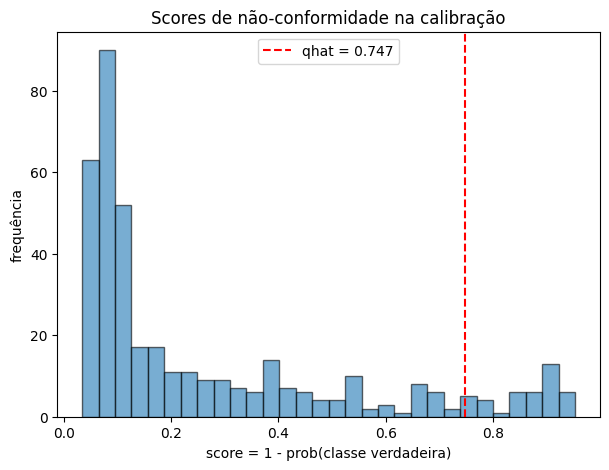

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(scores_cal, bins=30, alpha=0.6, edgecolor="black")
plt.axvline(qhat, color="red", linestyle="--", label=f"qhat = {qhat:.3f}")
plt.title("Scores de não-conformidade na calibração")
plt.xlabel("score = 1 - prob(classe verdadeira)")
plt.ylabel("frequência")
plt.legend()
plt.show()

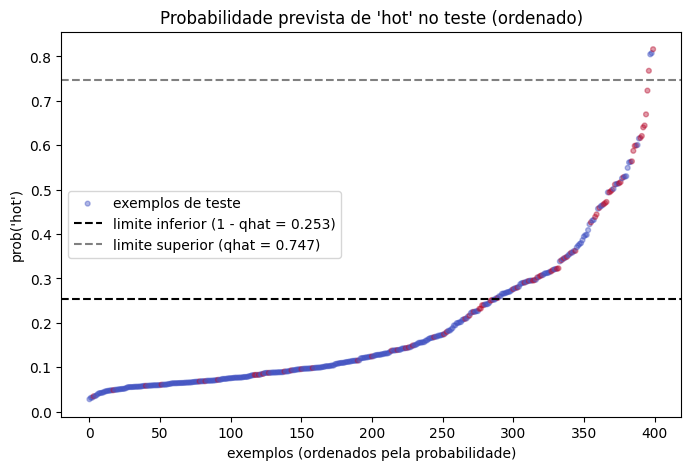

In [18]:
ordem = np.argsort(prob_teste[:, 1])
prob_hot_ord = prob_teste[ordem, 1]
y_real_ord = y_test.iloc[ordem]

plt.figure(figsize=(8, 5))
plt.scatter(range(len(prob_hot_ord)), prob_hot_ord, s=12, alpha=0.4,
            c=y_real_ord, cmap="coolwarm", label="exemplos de teste")
plt.axhline(1 - qhat, color="black", linestyle="--", label=f"limite inferior (1 - qhat = {1 - qhat:.3f})")
plt.axhline(qhat, color="gray", linestyle="--", label=f"limite superior (qhat = {qhat:.3f})")
plt.title("Probabilidade prevista de 'hot' no teste (ordenado)")
plt.xlabel("exemplos (ordenados pela probabilidade)")
plt.ylabel("prob('hot')")
plt.legend()
plt.show()

In [19]:
import lime
import lime.lime_tabular
import numpy as np
import os
import gc
import psutil
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


def log_ram(msg=""):
    """Mostra uso atual de RAM do processo"""
    proc = psutil.Process(os.getpid())
    mem_mb = proc.memory_info().rss / 1024 ** 2
    print(f"[RAM] {msg}: {mem_mb:.1f} MB")


def explicar_com_lime_disk(
    modelo,
    X_train_svd,
    X_test_svd,
    n_amostras=50,
    num_samples=300,       # perturbações por amostra (bem reduzido)
    num_features=None,     # None = todas; ou defina ex. 20
    batch_size=32,
    background_size=100,   # nº de linhas do X_train usadas no explainer
    out_dir="lime_resultados",
    checkpoint_a_cada=1
):
    """
    Versão para RAM extremamente limitada:
    - usa subconjunto de X_train como background
    - salva cada resultado em disco (não acumula tudo na RAM)
    - reduz num_samples e num_features
    - libera memória agressivamente a cada iteração
    """

    os.makedirs(out_dir, exist_ok=True)

    # Converte dados
    X_train = np.array(X_train_svd[0] if isinstance(X_train_svd, tuple) else X_train_svd)
    X_test = np.array(X_test_svd[0] if isinstance(X_test_svd, tuple) else X_test_svd)

    if X_train.ndim == 1:
        X_train = X_train.reshape(-1, 1)
    if X_test.ndim == 1:
        X_test = X_test.reshape(-1, 1)

    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    n_features = X_train.shape[1]
    if num_features is None:
        num_features = n_features

    # --- Reduz o background do LIME ---
    if background_size is not None and background_size < len(X_train):
        idx_bg = np.random.choice(len(X_train), size=background_size, replace=False)
        X_train_bg = X_train[idx_bg]
    else:
        X_train_bg = X_train

    del X_train  # não precisamos mais do treino inteiro
    gc.collect()
    log_ram("depois de reduzir background")

    feature_names = [f'feature_{i}' for i in range(n_features)]

    # --- predict_proba em mini-lotes ---
    def predict_proba_batched(X):
        X = np.asarray(X, dtype=np.float32)
        preds = []
        for i in range(0, len(X), batch_size):
            lote = X[i:i + batch_size]
            preds.append(modelo.predict_proba(lote))
            del lote
        out = np.vstack(preds)
        del preds
        return out

    explicador = lime.lime_tabular.LimeTabularExplainer(
        X_train_bg,
        feature_names=feature_names,
        class_names=['classe_0', 'classe_1'],
        mode='classification',
        training_data_stats=None,
        verbose=False
    )

    n_total = min(n_amostras, len(X_test))
    arquivos_salvos = []

    for i in tqdm(range(n_total), desc="Explicando com LIME"):
        amostra = X_test[i:i + 1]
        caminho_arquivo = os.path.join(out_dir, f"lime_{i:04d}.npy")

        # Se já existe (retomando de onde parou), pula
        if os.path.exists(caminho_arquivo):
            arquivos_salvos.append(caminho_arquivo)
            continue

        try:
            explicacao = explicador.explain_instance(
                amostra[0],
                predict_proba_batched,
                num_features=num_features,
                num_samples=num_samples,
                top_labels=1
            )

            valores = explicacao.local_exp[1]
            arr = np.zeros(n_features, dtype=np.float32)
            for idx, valor in valores:
                arr[idx] = valor

            # Salva no disco e descarta da RAM
            np.save(caminho_arquivo, arr)
            arquivos_salvos.append(caminho_arquivo)

            del explicacao, valores, arr

        except Exception as e:
            print(f"Erro na amostra {i}: {e}")
            arr = np.zeros(n_features, dtype=np.float32)
            np.save(caminho_arquivo, arr)
            arquivos_salvos.append(caminho_arquivo)

        del amostra

        if i % checkpoint_a_cada == 0:
            gc.collect()
            if i % 10 == 0:
                log_ram(f"amostra {i}")

    gc.collect()

    # --- Reconstroi o array final lendo do disco ---
    resultado_final = np.array([np.load(f) for f in arquivos_salvos])
    return resultado_final


# ---------------- Uso ----------------
lime_resultado = explicar_com_lime_disk(
    tabicl,
    X_train_svd,
    X_test_svd,
    n_amostras=50,
    num_samples=300,        # tente 150 se ainda estourar
    num_features=None,      # tente ex. 20 se tiver muitas features
    batch_size=32,          # tente 8 ou 16 se ainda estourar
    background_size=100,    # tente 50 se ainda estourar
    out_dir="lime_resultados"
)
print(f"Shape LIME: {lime_resultado.shape}")

[RAM] depois de reduzir background: 9306.2 MB


Explicando com LIME:   0%|          | 0/50 [00:00<?, ?it/s]

Erro na amostra 0: 1


Explicando com LIME:   2%|▏         | 1/50 [00:15<12:34, 15.40s/it]

[RAM] amostra 0: 4282.3 MB
Erro na amostra 1: 1


...

Erro na amostra 47: 1


Explicando com LIME:  98%|█████████▊| 49/50 [10:17<00:12, 12.59s/it]

Erro na amostra 48: 1
Erro na amostra 49: 1


Explicando com LIME: 100%|██████████| 50/50 [10:29<00:00, 12.60s/it]


Shape LIME: (50, 200)


In [20]:

n_features = lime_resultado.shape[1]
feature_names = [f'feature_{i}' for i in range(n_features)]

importancia_media = np.abs(lime_resultado).mean(axis=0)

df_importancia = pd.DataFrame({
    'feature': feature_names,
    'importancia_media': importancia_media
}).sort_values('importancia_media', ascending=False)

print(df_importancia.to_string(index=False))

    feature  importancia_media
  feature_3           0.005840
 feature_16           0.002442
 feature_43           0.002025
  feature_1           0.002017
feature_134           0.001835
  feature_0           0.001791
 feature_13           0.001737
feature_121           0.001632
 feature_33           0.001577
feature_116           0.001565
 feature_24           0.001530
 feature_56           0.001477
feature_118           0.001455
  feature_2           0.001363
feature_126           0.001320
 feature_28           0.001312
feature_145           0.001275
feature_100           0.001254
feature_153           0.001243
feature_151           0.001230
feature_125           0.001196
  feature_9           0.001182
 feature_77           0.001164
 feature_41           0.001133
feature_139           0.001123
 feature_30           0.001118
 feature_61           0.001099
feature_165           0.001077
 feature_26           0.001059
 feature_85           0.001025
 feature_45           0.001021
feature_

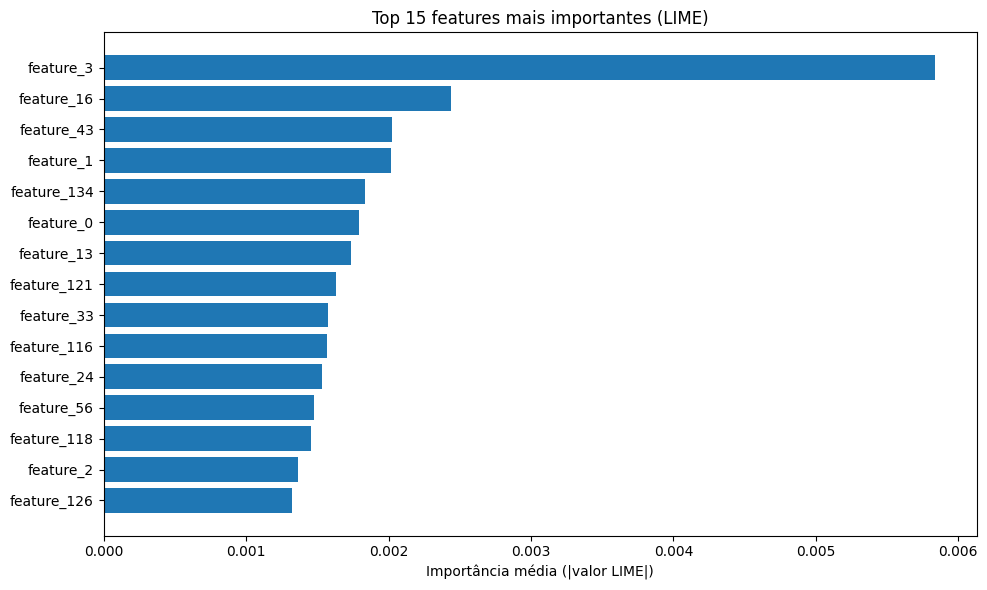

In [21]:
import matplotlib.pyplot as plt

top_n = 15
df_top = df_importancia.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(df_top['feature'], df_top['importancia_media'])
plt.xlabel('Importância média (|valor LIME|)')
plt.title(f'Top {top_n} features mais importantes (LIME)')
plt.gca().invert_yaxis()  # maior no topo
plt.tight_layout()
plt.show()

In [22]:
# ============================================
# BLOCO: INTERPRETAR COMPONENTES DO SVD EM PALAVRAS ORIGINAIS
# ============================================


# Vocabulário do TF-IDF (5000 palavras, na mesma ordem usada pelo SVD)
vocab = np.array(tfidf_vectorizer.get_feature_names_out())

def top_palavras_por_componente(componente_idx, top_n=8):
    """Retorna as palavras que mais pesam num componente do SVD, com sinal"""
    pesos = svd.components_[componente_idx]
    ordem = np.argsort(np.abs(pesos))[::-1][:top_n]
    return [(vocab[i], pesos[i]) for i in ordem]


def nomear_componente(componente_idx, top_n=3):
    """Cria um nome curto e legível pro componente, ex: C5(covid/vacina/saude)"""
    palavras = top_palavras_por_componente(componente_idx, top_n=top_n)
    nomes = [p[0] for p in palavras]
    return f"C{componente_idx}({'/'.join(nomes)})"


# --- 1. Mostra em detalhe os componentes mais importantes segundo o LIME ---
top_componentes_idx = (
    df_importancia['feature']
    .str.replace('feature_', '', regex=False)
    .astype(int)
    .tolist()
)

print("="*70)
print("PALAVRAS QUE COMPÕEM OS COMPONENTES MAIS IMPORTANTES (LIME)")
print("="*70)

for comp_idx in top_componentes_idx[:15]:  # top 15 componentes
    importancia = df_importancia[df_importancia['feature'] == f'feature_{comp_idx}']['importancia_media'].values[0]
    print(f"\n--- Componente {comp_idx} | importância LIME média: {importancia:.4f} ---")
    palavras = top_palavras_por_componente(comp_idx, top_n=8)
    for palavra, peso in palavras:
        sinal = "+" if peso > 0 else "-"
        print(f"   {sinal} {palavra:20s} (peso no SVD: {peso:+.4f})")


# --- 2. Cria nomes interpretáveis para TODOS os componentes ---
n_features = lime_resultado.shape[1]
nomes_interpretaveis = [nomear_componente(i, top_n=3) for i in range(n_features)]

# Atualiza o df_importancia com os nomes legíveis
df_importancia['nome_interpretavel'] = df_importancia['feature'].apply(
    lambda f: nomes_interpretaveis[int(f.replace('feature_', ''))]
)

print("\n" + "="*70)
print("RANKING DE IMPORTÂNCIA COM NOMES INTERPRETÁVEIS")
print("="*70)
print(df_importancia[['nome_interpretavel', 'importancia_media']].to_string(index=False))

PALAVRAS QUE COMPÕEM OS COMPONENTES MAIS IMPORTANTES (LIME)

--- Componente 3 | importância LIME média: 0.0058 ---
   + pic                  (peso no SVD: +0.3929)
   + twitter              (peso no SVD: +0.3900)
   + february             (peso no SVD: +0.2525)
   + diariogols           (peso no SVD: +0.2169)
   + 2026                 (peso no SVD: +0.2166)
   + diario               (peso no SVD: +0.1852)
   + torcedor             (peso no SVD: +0.1576)
   + escalacaosep         (peso no SVD: +0.1526)

--- Componente 16 | importância LIME média: 0.0024 ---
   + veiga                (peso no SVD: +0.2223)
   - sub                  (peso no SVD: -0.1744)
   + piquerez             (peso no SVD: +0.1657)
   + junior               (peso no SVD: +0.1442)
   + barranquilla         (peso no SVD: +0.1394)
   - paulinho             (peso no SVD: -0.1357)
   + carlos               (peso no SVD: +0.1348)
   + miguel               (peso no SVD: +0.1343)

--- Componente 43 | importância LIME média: 

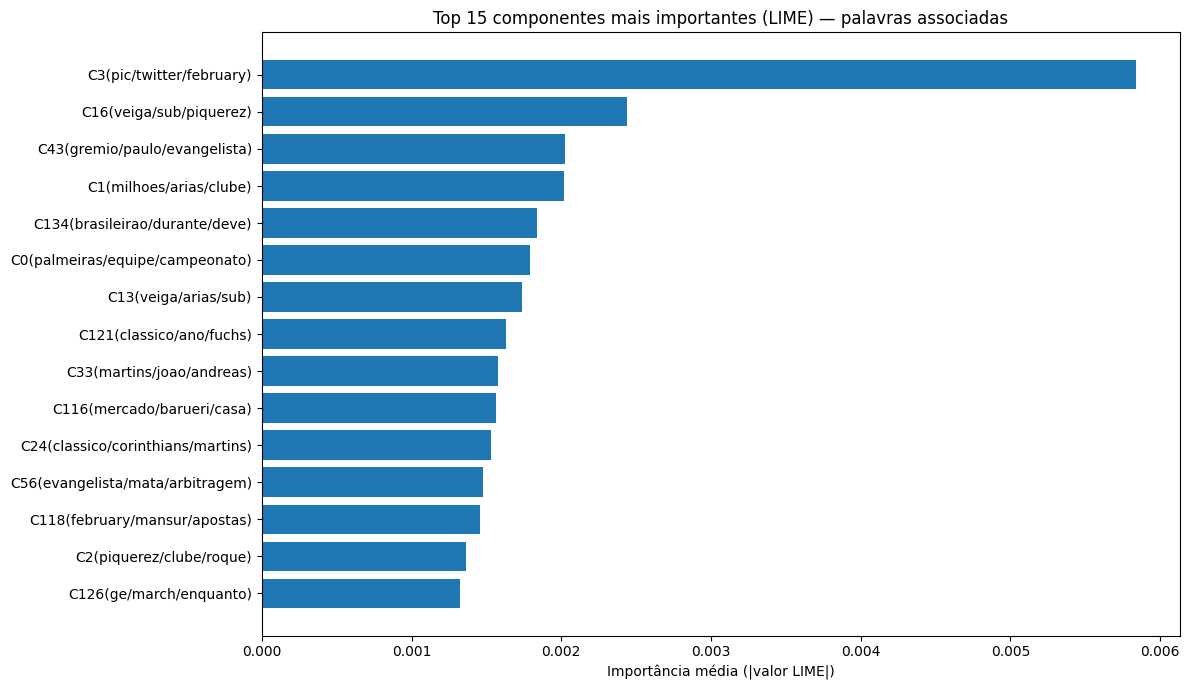

In [23]:
import matplotlib.pyplot as plt

top_n = 15
df_top = df_importancia.head(top_n)

plt.figure(figsize=(12, 7))
plt.barh(df_top['nome_interpretavel'], df_top['importancia_media'])
plt.xlabel('Importância média (|valor LIME|)')
plt.title(f'Top {top_n} componentes mais importantes (LIME) — palavras associadas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()